# Project Data Engineer — Transjakarta Public Transportation Transaction

**Dataset**: [Transjakarta Transportation Transaction (Kaggle)](https://www.kaggle.com/datasets/dikisahkan/transjakarta-transportation-transaction)

**Objective:**
Melakukan proses Data Engineering yang lengkap meliputi:
1. **Data Cleansing** & **Data Quality Check**
2. **Data Governance** & **Medallion Architecture** (Bronze → Silver → Gold)
3. **Privacy Policy** — Masking data sensitif
4. **Metadata Strategy** — Data Dictionary
5. **Analisis Data** & **Visualisasi** dengan insight
6. **Export** data bersih ke **Excel** dan **MySQL**

---

## 📖 Apa itu Data Governance?

**Data Governance** adalah kerangka kerja yang mencakup kebijakan, proses, standar, dan metrik yang memastikan pengelolaan data secara efektif dan efisien di seluruh organisasi.

### Komponen utama Data Governance:
| Komponen | Deskripsi |
|----------|-----------|
| **Data Quality** | Memastikan data akurat, lengkap, konsisten, dan valid |
| **Data Privacy** | Melindungi data sensitif melalui masking, encryption, atau anonymization |
| **Data Architecture** | Menerapkan arsitektur data yang terstruktur (contoh: Medallion Architecture) |
| **Metadata Management** | Mendokumentasikan data melalui Data Dictionary dan data catalog |
| **Data Lineage** | Melacak asal-usul dan transformasi data dari sumber ke tujuan |

### Medallion Architecture
Medallion Architecture adalah pola arsitektur data yang membagi data menjadi **tiga layer**:
- **🥉 Bronze Layer**: Data mentah (raw) langsung dari sumber tanpa transformasi
- **🥈 Silver Layer**: Data yang sudah dibersihkan, divalidasi, dan di-enrichment
- **🥇 Gold Layer**: Data yang sudah di-agregasi dan siap untuk analisis/reporting

---

## ⚙️ Setup & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Load Dataset

In [2]:
# Load dataset dari file CSV
DATA_PATH = r'Transjakarta - Public Transportation Transaction/dfTransjakarta180kRows.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
df_raw.head()

Dataset loaded: 189,500 baris × 22 kolom


,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,VRPJ892P3M98RA,3561407960318444,dki,"Dr. Janet Nashiruddin, M.Ak",M,2010,4,Pulo Gadung 2 - Tosari,1.00,P00167,Pemuda Rawamangun,-6.19,106.89,12,2023-04-03 06:53:02,P00127,Layur,-6.19,106.90,13.00,2023-04-03 07:13:28,3500.00
1,ZWCH834I6M26HS,347728053419394,emoney,Balamantri Rahayu,M,2002,JAK.28,Kp. Rambutan - Taman Wiladatika,1.00,B04633P,Sekolah Islam PB Soedirman,-6.31,106.86,27,2023-04-03 05:59:19,B00865P,Jln. Ar Ridho,-6.31,106.87,30.00,2023-04-03 06:57:06,0.00
2,YRLD835V6L82GO,377105453850671,emoney,Dian Mustofa,F,1993,B13,Bekasi Barat - Blok M,1.00,B02192P,Mall Metropolitan,-6.25,106.99,6,2023-04-03 05:13:24,B00108P,Bandar Djakarta Bekasi,-6.23,107.00,9.00,2023-04-03 06:01:23,20000.00
3,ZZBX143N6N83HQ,4486493302356581,dki,"Cut Janet Suryatmi, M.Ak",M,1980,8K,Batusari - Grogol,1.00,B03637P,Sbr. Jln. Angsana Kemanggisan,-6.19,106.78,16,2023-04-03 05:20:24,NaN,Yayasan Alkahfi Jakbar,-6.20,106.77,26.00,2023-04-03 06:01:25,3500.00
4,EWEG491A2W45DR,30139379978125,bni,"dr. Mulyanto Pudjiastuti, M.Ak",F,1997,NaN,NaN,0.00,NaN,BRI Menteng,-6.19,106.84,2,2023-04-03 06:00:54,B02755P,Perpustakaan Nasional,-6.18,106.83,5.00,2023-04-03 06:47:32,3500.00


## 🔍 Data Understanding

Tahap pertama dalam Data Engineering adalah **memahami data** yang akan diolah. Kita perlu mengetahui struktur, tipe data, distribusi, dan kualitas data sebelum melakukan transformasi apapun.

---

In [3]:
# Informasi umum dataset
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"Jumlah Baris    : {df_raw.shape[0]:,}")
print(f"Jumlah Kolom    : {df_raw.shape[1]}")
print(f"Memory Usage    : {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
df_raw.info()

INFORMASI DATASET
Jumlah Baris    : 189,500
Jumlah Kolom    : 22
Memory Usage    : 146.41 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189500 entries, 0 to 189499
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transID           189500 non-null  object 
 1   payCardID         189500 non-null  int64  
 2   payCardBank       189500 non-null  object 
 3   payCardName       189500 non-null  object 
 4   payCardSex        189500 non-null  object 
 5   payCardBirthDate  189500 non-null  int64  
 6   corridorID        182520 non-null  object 
 7   corridorName      175972 non-null  object 
 8   direction         189500 non-null  float64
 9   tapInStops        182259 non-null  object 
 10  tapInStopsName    189500 non-null  object 
 11  tapInStopsLat     189500 non-null  float64
 12  tapInStopsLon     189500 non-null  float64
 13  stopStartSeq      189500 non-null  int64  
 14  tapInTime         1895

In [4]:
# Statistik deskriptif
print("STATISTIK DESKRIPTIF — Kolom Numerik")
print("=" * 60)
df_raw.describe()

STATISTIK DESKRIPTIF — Kolom Numerik


,payCardID,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapOutStopsLat,tapOutStopsLon,stopEndSeq,payAmount
count,189500.00,189500.00,189500.00,189500.00,189500.00,189500.00,182780.00,182780.00,182780.00,185782.00
mean,394166420948976512.00,1990.16,0.50,-6.21,106.84,13.40,-6.21,106.84,20.92,2673.22
std,1272012666738117376.00,13.45,0.50,0.06,0.06,12.14,0.06,0.06,13.93,4136.60
min,60404484630.00,1946.00,0.00,-6.39,106.61,0.00,-6.39,106.61,1.00,0.00
25%,180004429530433.00,1982.00,0.00,-6.25,106.80,4.00,-6.25,106.80,11.00,0.00
50%,3519005268452064.00,1991.00,1.00,-6.21,106.84,10.00,-6.21,106.84,18.00,3500.00
75%,4664460720356463.00,2001.00,1.00,-6.17,106.88,19.00,-6.17,106.88,29.00,3500.00
max,4999813783000465408.00,2012.00,1.00,-6.09,107.02,75.00,-6.09,107.02,77.00,20000.00


In [5]:
# Analisis Missing Values
print("ANALISIS MISSING VALUES")
print("=" * 60)
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Jumlah Missing': missing.values,
    'Persentase (%)': missing_pct.values
}).sort_values('Jumlah Missing', ascending=False)
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].reset_index(drop=True)
print(missing_df.to_string(index=False))
print(f"\nTotal missing values: {missing}")
print(f"\nTotal kolom dengan missing values: {len(missing_df)}")

ANALISIS MISSING VALUES
          Kolom  Jumlah Missing  Persentase (%)
   corridorName           13528            7.14
    tapOutStops           12369            6.53
     tapInStops            7241            3.82
     corridorID            6980            3.68
     tapOutTime            6720            3.55
     stopEndSeq            6720            3.55
 tapOutStopsLon            6720            3.55
 tapOutStopsLat            6720            3.55
tapOutStopsName            6720            3.55
      payAmount            3718            1.96

Total missing values: transID                 0
payCardID               0
payCardBank             0
payCardName             0
payCardSex              0
payCardBirthDate        0
corridorID           6980
corridorName        13528
direction               0
tapInStops           7241
tapInStopsName          0
tapInStopsLat           0
tapInStopsLon           0
stopStartSeq            0
tapInTime               0
tapOutStops         12369
tapOutSto

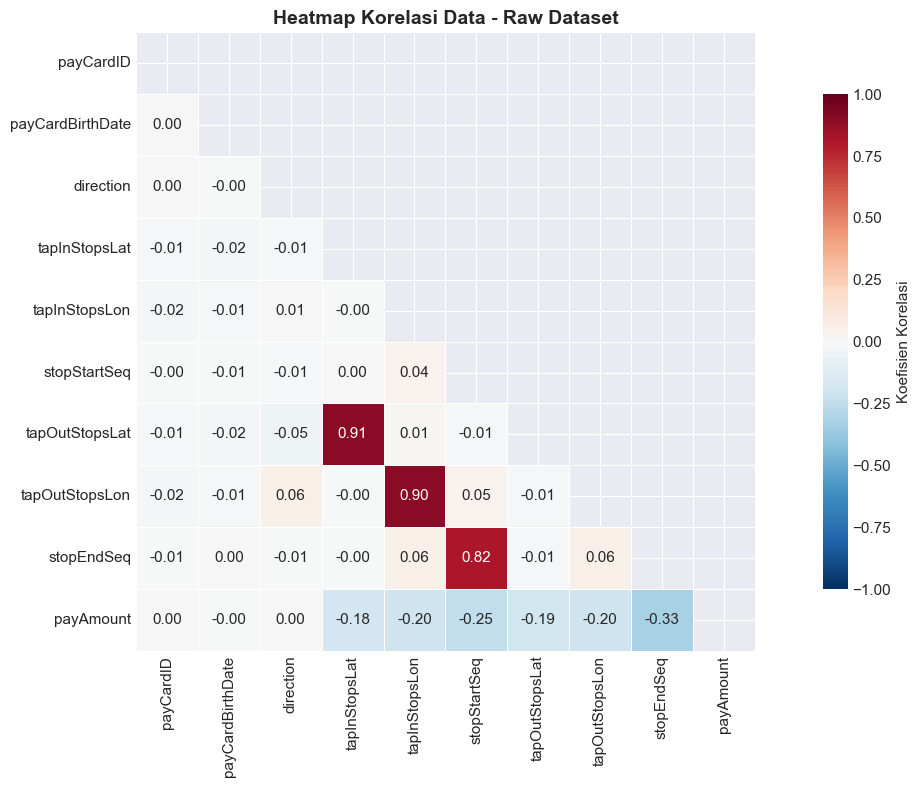


INSIGHT:
   Top 5 pasangan variabel dengan korelasi tertinggi:
   - tapInStopsLat <-> tapOutStopsLat: 0.906 (positif)
   - tapOutStopsLon <-> tapInStopsLon: 0.903 (positif)
   - stopEndSeq <-> stopStartSeq: 0.820 (positif)
   - stopEndSeq <-> payAmount: -0.326 (negatif)
   - payAmount <-> stopStartSeq: -0.248 (negatif)


In [6]:
# Analisis korelasi dengan heatmap
# Pilih hanya kolom numerik untuk korelasi
numeric_df = df_raw.select_dtypes(include=[np.number])

fig, ax = plt.subplots(figsize=(14, 8))
corr_matrix = numeric_df.corr()

# Mask segitiga atas untuk tampilan lebih bersih
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
    ax=ax
)
ax.set_title('Heatmap Korelasi Data - Raw Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nINSIGHT:")
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Var1', 'Var2', 'Correlation']
corr_pairs = corr_pairs[corr_pairs['Var1'] != corr_pairs['Var2']]
corr_pairs['AbsCorr'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.sort_values('AbsCorr', ascending=False).drop_duplicates(subset=['AbsCorr'])
print("   Top 5 pasangan variabel dengan korelasi tertinggi:")
for _, row in corr_pairs.head(5).iterrows():
    direction = "positif" if row['Correlation'] > 0 else "negatif"
    print(f"   - {row['Var1']} <-> {row['Var2']}: {row['Correlation']:.3f} ({direction})")

## 🥉 Bronze Layer — Raw Data Ingestion

### Apa itu Bronze Layer?
Bronze Layer adalah **lapisan pertama** dalam Medallion Architecture. Data di layer ini adalah **data mentah (raw)** yang langsung diambil dari sumber tanpa modifikasi apapun.

**Tujuan Bronze Layer:**
- Menyimpan data asli sebagai *single source of truth*
- Menambahkan metadata ingestion (waktu masuk, sumber file)
- Menjadi titik awal untuk re-processing jika diperlukan

---

In [7]:
# === BRONZE LAYER ===
# Copy data mentah dan tambahkan metadata ingestion
df_bronze = df_raw.copy()

# Tambahkan metadata columns
df_bronze['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
df_bronze['_source_file'] = 'dfTransjakarta180kRows.csv'
df_bronze['_source_origin'] = 'Kaggle - Transjakarta Transportation Transaction'
df_bronze['_record_id'] = range(1, len(df_bronze) + 1)
df_bronze['_layer'] = 'bronze'

print(f"✅ Bronze Layer created: {df_bronze.shape[0]:,} rows × {df_bronze.shape[1]} columns")
print(f"   Metadata columns added: _ingestion_timestamp, _source_file, _source_origin, _record_id, _layer")
df_bronze.head(3)

✅ Bronze Layer created: 189,500 rows × 27 columns
   Metadata columns added: _ingestion_timestamp, _source_file, _source_origin, _record_id, _layer


,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,_ingestion_timestamp,_source_file,_source_origin,_record_id,_layer
0,VRPJ892P3M98RA,3561407960318444,dki,"Dr. Janet Nashiruddin, M.Ak",M,2010,4,Pulo Gadung 2 - Tosari,1.00,P00167,Pemuda Rawamangun,-6.19,106.89,12,2023-04-03 06:53:02,P00127,Layur,-6.19,106.90,13.00,2023-04-03 07:13:28,3500.00,2026-03-31 17:08:18,dfTransjakarta180kRows.csv,Kaggle - Transjakarta Transportation Transaction,1,bronze
1,ZWCH834I6M26HS,347728053419394,emoney,Balamantri Rahayu,M,2002,JAK.28,Kp. Rambutan - Taman Wiladatika,1.00,B04633P,Sekolah Islam PB Soedirman,-6.31,106.86,27,2023-04-03 05:59:19,B00865P,Jln. Ar Ridho,-6.31,106.87,30.00,2023-04-03 06:57:06,0.00,2026-03-31 17:08:18,dfTransjakarta180kRows.csv,Kaggle - Transjakarta Transportation Transaction,2,bronze
2,YRLD835V6L82GO,377105453850671,emoney,Dian Mustofa,F,1993,B13,Bekasi Barat - Blok M,1.00,B02192P,Mall Metropolitan,-6.25,106.99,6,2023-04-03 05:13:24,B00108P,Bandar Djakarta Bekasi,-6.23,107.00,9.00,2023-04-03 06:01:23,20000.00,2026-03-31 17:08:18,dfTransjakarta180kRows.csv,Kaggle - Transjakarta Transportation Transaction,3,bronze


## 🥈 Silver Layer — Data Cleansing & Quality Check

### Apa itu Data Quality Check?
**Data Quality Check** adalah proses sistematis untuk mengevaluasi dan memastikan kualitas data berdasarkan beberapa dimensi:

| Dimensi | Deskripsi | Contoh Pengecekan |
|---------|-----------|-------------------|
| **Completeness** | Data tidak memiliki nilai kosong yang signifikan | Cek missing values pada setiap kolom |
| **Consistency** | Data seragam dan tidak bertentangan | Format tanggal yang sama, satuan yang konsisten |
| **Validity** | Data sesuai dengan aturan bisnis | Umur tidak negatif, koordinat dalam range valid |
| **Uniqueness** | Tidak ada duplikasi yang tidak diinginkan | Cek duplicate transID |
| **Timeliness** | Data masih relevan dan up-to-date | Cek range tanggal transaksi |

### Apa itu Data Cleansing?
**Data Cleansing** (pembersihan data) adalah proses mendeteksi dan memperbaiki (atau menghapus) data yang corrupt, tidak akurat, atau tidak relevan dari dataset.

---

In [8]:
# === SILVER LAYER — Step 1: Start from Bronze ===
df_silver = df_bronze.copy()
df_silver['_layer'] = 'silver'

# Hapus metadata columns yang tidak perlu untuk analisis
meta_cols = ['_ingestion_timestamp', '_source_file', '_source_origin', '_record_id', '_layer']
analysis_cols = [c for c in df_silver.columns if c not in meta_cols]

print("📊 DATA QUALITY CHECK — SEBELUM CLEANSING")
print("=" * 60)

# 1. Completeness Check
print("\n1️⃣ COMPLETENESS CHECK")
total_cells = df_silver[analysis_cols].shape[0] * df_silver[analysis_cols].shape[1]
missing_cells = df_silver[analysis_cols].isnull().sum().sum()
completeness = ((total_cells - missing_cells) / total_cells * 100)
print(f"   Total cells       : {total_cells:,}")
print(f"   Missing cells     : {missing_cells:,}")
print(f"   Completeness Rate : {completeness:.2f}%")

# 2. Uniqueness Check
print("\n2️⃣ UNIQUENESS CHECK")
duplicates = df_silver.duplicated(subset=['transID']).sum()
print(f"   Duplicate transID : {duplicates:,}")
print(f"   Uniqueness Rate   : {((len(df_silver) - duplicates) / len(df_silver) * 100):.2f}%")

# 3. Validity Check
print("\n3️⃣ VALIDITY CHECK")
print(f"   payAmount < 0     : {(df_silver['payAmount'] < 0).sum()}")
print(f"   direction values  : {sorted(df_silver['direction'].dropna().unique())}")
invalid_lat = ((df_silver['tapInStopsLat'].abs() > 90) | (df_silver['tapOutStopsLat'].abs() > 90)).sum()
print(f"   Invalid Latitude  : {invalid_lat}")

# 4. Consistency Check
print("\n4️⃣ CONSISTENCY CHECK")
print(f"   payCardSex values : {df_silver['payCardSex'].unique()}")
print(f"   payCardBank unique: {df_silver['payCardBank'].nunique()}")

📊 DATA QUALITY CHECK — SEBELUM CLEANSING

1️⃣ COMPLETENESS CHECK
   Total cells       : 4,169,000
   Missing cells     : 77,436
   Completeness Rate : 98.14%

2️⃣ UNIQUENESS CHECK
   Duplicate transID : 0
   Uniqueness Rate   : 100.00%

3️⃣ VALIDITY CHECK
   payAmount < 0     : 0
   direction values  : [0.0, 1.0]
   Invalid Latitude  : 0

4️⃣ CONSISTENCY CHECK
   payCardSex values : ['M' 'F']
   payCardBank unique: 6


In [9]:
# === SILVER LAYER — Step 2: Data Cleansing ===
print("🧹 DATA CLEANSING PROCESS")
print("=" * 60)

# 2a. Remove exact duplicates
before = len(df_silver)
df_silver = df_silver.drop_duplicates(subset=['transID'], keep='first')
print(f"\n✅ Removed {before - len(df_silver):,} duplicate rows")

# 2b. Fix data types — datetime columns
df_silver['tapInTime'] = pd.to_datetime(df_silver['tapInTime'], errors='coerce')
df_silver['tapOutTime'] = pd.to_datetime(df_silver['tapOutTime'], errors='coerce')
print("✅ Converted tapInTime & tapOutTime to datetime")

# 2c. Fix payCardBirthDate — convert to age
current_year = datetime.now().year
df_silver['payCardBirthDate'] = pd.to_numeric(df_silver['payCardBirthDate'], errors='coerce')
df_silver['age'] = current_year - df_silver['payCardBirthDate']
# Cap unrealistic ages
df_silver.loc[df_silver['age'] < 0, 'age'] = np.nan
df_silver.loc[df_silver['age'] > 120, 'age'] = np.nan
print("✅ Created 'age' column from payCardBirthDate")

# 2d. Extract time features
df_silver['tapInHour'] = df_silver['tapInTime'].dt.hour
df_silver['tapInDate'] = df_silver['tapInTime'].dt.date
df_silver['tapInDayOfWeek'] = df_silver['tapInTime'].dt.day_name()
print("✅ Extracted time features: tapInHour, tapInDate, tapInDayOfWeek")

# 2e. Handle missing values
# corridorID & corridorName — fill with 'Unknown'
df_silver['corridorID'] = df_silver['corridorID'].fillna('Unknown')
df_silver['corridorName'] = df_silver['corridorName'].fillna('Unknown')
print("✅ Filled missing corridorID & corridorName with 'Unknown'")

# tapInStops & tapOutStops — fill with 'Unknown'
df_silver['tapInStops'] = df_silver['tapInStops'].fillna('Unknown')
df_silver['tapOutStops'] = df_silver['tapOutStops'].fillna('Unknown')
df_silver['tapOutStopsName'] = df_silver['tapOutStopsName'].fillna('Unknown')
print("✅ Filled missing stop columns with 'Unknown'")

# tapOutStopsLat/Lon — fill with 0
df_silver['tapOutStopsLat'] = df_silver['tapOutStopsLat'].fillna(0)
df_silver['tapOutStopsLon'] = df_silver['tapOutStopsLon'].fillna(0)
print("✅ Filled missing coordinates with 0")

# stopEndSeq — fill with 0
df_silver['stopEndSeq'] = df_silver['stopEndSeq'].fillna(0).astype(int)
print("✅ Filled missing stopEndSeq with 0")

# payAmount — fill with median
pay_median = df_silver['payAmount'].median()
df_silver['payAmount'] = df_silver['payAmount'].fillna(pay_median)
print(f"✅ Filled missing payAmount with median ({pay_median:,.0f})")

# 2f. Create age group
bins = [0, 17, 25, 35, 45, 55, 65, 120]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_silver['ageGroup'] = pd.cut(df_silver['age'], bins=bins, labels=labels)
print("✅ Created 'ageGroup' column")

# Add cleaned timestamp
df_silver['_cleaned_timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

print(f"\n📊 Silver Layer: {df_silver.shape[0]:,} rows × {df_silver.shape[1]} columns")

🧹 DATA CLEANSING PROCESS

✅ Removed 0 duplicate rows
✅ Converted tapInTime & tapOutTime to datetime
✅ Created 'age' column from payCardBirthDate
✅ Extracted time features: tapInHour, tapInDate, tapInDayOfWeek
✅ Filled missing corridorID & corridorName with 'Unknown'
✅ Filled missing stop columns with 'Unknown'
✅ Filled missing coordinates with 0
✅ Filled missing stopEndSeq with 0
✅ Filled missing payAmount with median (3,500)
✅ Created 'ageGroup' column

📊 Silver Layer: 189,500 rows × 33 columns


In [10]:
# === DATA QUALITY CHECK — SETELAH CLEANSING ===
print("📊 DATA QUALITY CHECK — SETELAH CLEANSING")
print("=" * 60)

check_cols = [c for c in df_silver.columns if not c.startswith('_')]

# 1. Completeness
total_cells = df_silver[check_cols].shape[0] * df_silver[check_cols].shape[1]
missing_cells = df_silver[check_cols].isnull().sum().sum()
completeness_after = ((total_cells - missing_cells) / total_cells * 100)
print(f"\n1️⃣ Completeness Rate : {completeness_after:.2f}% (sebelumnya: {completeness:.2f}%)")

# 2. Uniqueness
dup_after = df_silver.duplicated(subset=['transID']).sum()
print(f"2️⃣ Duplicate transID : {dup_after}")

# 3. Missing values remaining
remaining_missing = df_silver[check_cols].isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) > 0:
    print(f"3️⃣ Remaining missing values:")
    for col, val in remaining_missing.items():
        print(f"   {col}: {val:,} ({val/len(df_silver)*100:.2f}%)")
else:
    print("3️⃣ No significant missing values remaining ✅")

# Quality Score
quality_score = completeness_after
df_silver['_quality_score'] = round(quality_score, 2)
print(f"\n⭐ Overall Data Quality Score: {quality_score:.2f}%")

📊 DATA QUALITY CHECK — SETELAH CLEANSING

1️⃣ Completeness Rate : 99.87% (sebelumnya: 98.14%)
2️⃣ Duplicate transID : 0
3️⃣ Remaining missing values:
   tapOutTime: 6,720 (3.55%)

⭐ Overall Data Quality Score: 99.87%


## 🔒 Privacy Policy — Data Masking

### Apa itu Privacy Policy dalam Data Engineering?
**Privacy Policy** adalah kebijakan perlindungan data yang memastikan bahwa **informasi pribadi (PII - Personally Identifiable Information)** dilindungi dari akses yang tidak sah.

### Kolom PII yang akan di-mask:
| Kolom | Tipe PII | Metode Masking |
|-------|----------|----------------|
| `payCardID` | Nomor kartu | Tampilkan 4 digit terakhir saja (`****5671`) |
| `payCardName` | Nama penumpang | Partial masking (`A*** S***`) |
| `payCardBirthDate` | Tahun lahir | Diganti dengan age group (sudah dilakukan) |

### Mengapa Data Masking penting?
1. **Kepatuhan regulasi** (GDPR, UU PDP Indonesia)
2. **Mencegah kebocoran data** sensitif
3. **Memungkinkan analisis** tanpa mengekspos identitas individu

---

In [11]:
# === PRIVACY POLICY — DATA MASKING ===
print("🔒 DATA MASKING PROCESS")
print("=" * 60)

def mask_card_id(card_id):
    """Mask kartu: tampilkan 4 digit terakhir"""
    s = str(card_id)
    if len(s) <= 4:
        return '****'
    return '*' * (len(s) - 4) + s[-4:]

def mask_name(name):
    """Mask nama: tampilkan huruf pertama setiap kata"""
    if pd.isna(name) or str(name).strip() == '':
        return '***'
    words = str(name).split()
    masked = []
    for w in words:
        if len(w) <= 1:
            masked.append(w[0] + '***')
        else:
            masked.append(w[0] + '*' * (len(w) - 1))
    return ' '.join(masked)

# Show before masking
print("\n📋 SEBELUM Masking:")
print(df_silver[['payCardID', 'payCardName', 'payCardBirthDate']].head(5).to_string())

# Apply masking
df_silver['payCardID_masked'] = df_silver['payCardID'].apply(mask_card_id)
df_silver['payCardName_masked'] = df_silver['payCardName'].apply(mask_name)

# Replace original columns with masked versions
df_silver['payCardID_original'] = df_silver['payCardID']  # Keep backup
df_silver['payCardName_original'] = df_silver['payCardName']  # Keep backup
df_silver['payCardID'] = df_silver['payCardID_masked']
df_silver['payCardName'] = df_silver['payCardName_masked']

# Drop helper columns from export
df_silver.drop(columns=['payCardID_masked', 'payCardName_masked'], inplace=True)

print("\n📋 SETELAH Masking:")
print(df_silver[['payCardID', 'payCardName', 'ageGroup']].head(5).to_string())
print("\n✅ Data masking berhasil diterapkan!")
print("   - payCardID    → hanya 4 digit terakhir terlihat")
print("   - payCardName  → hanya huruf pertama setiap kata terlihat")
print("   - payCardBirthDate → diganti dengan ageGroup")

🔒 DATA MASKING PROCESS

📋 SEBELUM Masking:
          payCardID                     payCardName  payCardBirthDate
0  3561407960318444     Dr. Janet Nashiruddin, M.Ak              2010
1   347728053419394               Balamantri Rahayu              2002
2   377105453850671                    Dian Mustofa              1993
3  4486493302356581        Cut Janet Suryatmi, M.Ak              1980
4    30139379978125  dr. Mulyanto Pudjiastuti, M.Ak              1997

📋 SETELAH Masking:
          payCardID                     payCardName ageGroup
0  ************8444     D** J**** N*********** M***      <18
1   ***********9394               B********* R*****    18-25
2   ***********0671                    D*** M******    26-35
3  ************6581        C** J**** S******** M***    46-55
4    **********8125  d** M******* P*********** M***    26-35

✅ Data masking berhasil diterapkan!
   - payCardID    → hanya 4 digit terakhir terlihat
   - payCardName  → hanya huruf pertama setiap kata terlihat
 

## 🥇 Gold Layer — Aggregated & Analytics-Ready Data

### Apa itu Gold Layer?
Gold Layer adalah **lapisan terakhir** dalam Medallion Architecture yang berisi data yang sudah **di-agregasi** dan **siap digunakan** untuk analisis, reporting, atau machine learning.

**Karakteristik Gold Layer:**
- Data sudah bersih dan tervalidasi
- Sudah di-agregasi sesuai kebutuhan bisnis
- Optimized untuk query dan reporting
- Tidak mengandung PII (data sudah di-mask)

Pada project ini, kita membuat beberapa **Gold Tables**:
1. **Transaksi per Corridor** — revenue dan jumlah transaksi per corridor
2. **Traffic per Jam** — distribusi transaksi per jam
3. **Demografi Penumpang** — statistik berdasarkan gender dan age group
4. **Daily Trend** — trend transaksi harian

---

In [12]:
# === GOLD LAYER — Aggregated Tables ===
print("🥇 GOLD LAYER — Creating Aggregated Tables")
print("=" * 60)

# Gold Table 1: Corridor Summary
gold_corridor = df_silver.groupby(['corridorID', 'corridorName']).agg(
    total_transactions=('transID', 'count'),
    total_revenue=('payAmount', 'sum'),
    avg_revenue=('payAmount', 'mean'),
    unique_passengers=('payCardID', 'nunique')
).reset_index().sort_values('total_transactions', ascending=False)
gold_corridor['_aggregation_timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
gold_corridor['_layer'] = 'gold'
print(f"✅ Gold Table 1 — Corridor Summary: {gold_corridor.shape[0]} rows")

# Gold Table 2: Hourly Traffic
gold_hourly = df_silver.groupby('tapInHour').agg(
    total_transactions=('transID', 'count'),
    total_revenue=('payAmount', 'sum'),
    avg_revenue=('payAmount', 'mean')
).reset_index()
gold_hourly['_aggregation_timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
gold_hourly['_layer'] = 'gold'
print(f"✅ Gold Table 2 — Hourly Traffic: {gold_hourly.shape[0]} rows")

# Gold Table 3: Demographics Summary
gold_demographics = df_silver.groupby(['payCardSex', 'ageGroup']).agg(
    total_transactions=('transID', 'count'),
    total_revenue=('payAmount', 'sum'),
    avg_revenue=('payAmount', 'mean')
).reset_index()
gold_demographics['_aggregation_timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
gold_demographics['_layer'] = 'gold'
print(f"✅ Gold Table 3 — Demographics: {gold_demographics.shape[0]} rows")

# Gold Table 4: Daily Trend
gold_daily = df_silver.groupby('tapInDate').agg(
    total_transactions=('transID', 'count'),
    total_revenue=('payAmount', 'sum'),
    unique_passengers=('payCardID', 'nunique')
).reset_index()
gold_daily['tapInDate'] = pd.to_datetime(gold_daily['tapInDate'])
gold_daily['_aggregation_timestamp'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
gold_daily['_layer'] = 'gold'
print(f"✅ Gold Table 4 — Daily Trend: {gold_daily.shape[0]} rows")

print(f"\n📊 Total Gold Tables: 4")

🥇 GOLD LAYER — Creating Aggregated Tables
✅ Gold Table 1 — Corridor Summary: 655 rows
✅ Gold Table 2 — Hourly Traffic: 17 rows
✅ Gold Table 3 — Demographics: 14 rows
✅ Gold Table 4 — Daily Trend: 30 rows

📊 Total Gold Tables: 4


In [13]:
# Preview Gold Tables
print("📋 PREVIEW GOLD TABLES")
print("=" * 60)

print("\n🏆 Top 10 Corridors by Transactions:")
print(gold_corridor[['corridorName', 'total_transactions', 'total_revenue', 'unique_passengers']].head(10).to_string(index=False))

print("\n⏰ Hourly Traffic:")
print(gold_hourly[['tapInHour', 'total_transactions', 'total_revenue']].to_string(index=False))

📋 PREVIEW GOLD TABLES

🏆 Top 10 Corridors by Transactions:
                        corridorName  total_transactions  total_revenue  unique_passengers
                             Unknown                5707    15518000.00               3426
     Rusun Penjaringan - Penjaringan                1207     4224500.00                 96
              Pulo Gebang - Matraman                1183     4140500.00                108
                   Ciledug - Tendean                1150     4025000.00                 99
            Kalimalang - Duren Sawit                1121           0.00                101
                 Bintaro - Fatmawati                1101    22020000.00                 95
               Matraman Baru - Ancol                1099     3846500.00                113
      Kampung Rambutan - Bidara Cina                1095     3832500.00                104
Rusun Pinus Elok - Rusun Pulo Gebang                1078           0.00                101
                Harapan Indah -

## 📚 Metadata Strategy — Data Dictionary

### Apa itu Metadata Strategy?
**Metadata Strategy** adalah pendekatan terstruktur untuk mendokumentasikan, mengelola, dan memanfaatkan metadata (data tentang data) dalam suatu organisasi.

### Apa itu Data Dictionary?
**Data Dictionary** adalah dokumen yang menjelaskan struktur, definisi, dan atribut dari setiap elemen data dalam dataset. Ini berfungsi sebagai **referensi utama** bagi semua pengguna data.

**Manfaat Data Dictionary:**
- Memastikan **pemahaman yang seragam** tentang setiap kolom
- Mempermudah **onboarding** anggota tim baru
- Mendukung **audit** dan **compliance**
- Menjadi bagian dari **data catalog** organisasi

---

In [14]:
# === DATA DICTIONARY ===
print("📚 DATA DICTIONARY — Silver Layer")
print("=" * 80)

data_dict = [
    ['transID', 'object', 'ID unik transaksi', 'No', 'No'],
    ['payCardID', 'object', 'ID kartu pembayaran (MASKED)', 'No', 'Yes ⚠️'],
    ['payCardBank', 'object', 'Bank penerbit kartu', 'No', 'No'],
    ['payCardName', 'object', 'Nama pemegang kartu (MASKED)', 'No', 'Yes ⚠️'],
    ['payCardSex', 'object', 'Jenis kelamin pemegang kartu (F/M)', 'No', 'No'],
    ['payCardBirthDate', 'int64', 'Tahun lahir pemegang kartu', 'No', 'Yes ⚠️'],
    ['corridorID', 'object', 'ID koridor TransJakarta', 'No', 'No'],
    ['corridorName', 'object', 'Nama koridor TransJakarta', 'No', 'No'],
    ['direction', 'float64', 'Arah perjalanan (0=Pergi, 1=Pulang)', 'No', 'No'],
    ['tapInStops', 'object', 'ID halte tap in', 'No', 'No'],
    ['tapInStopsName', 'object', 'Nama halte tap in', 'No', 'No'],
    ['tapInStopsLat', 'float64', 'Latitude halte tap in', 'No', 'No'],
    ['tapInStopsLon', 'float64', 'Longitude halte tap in', 'No', 'No'],
    ['stopStartSeq', 'int64', 'Urutan halte tap in', 'No', 'No'],
    ['tapInTime', 'datetime64', 'Waktu tap in', 'No', 'No'],
    ['tapOutStops', 'object', 'ID halte tap out', 'Yes', 'No'],
    ['tapOutStopsName', 'object', 'Nama halte tap out', 'Yes', 'No'],
    ['tapOutStopsLat', 'float64', 'Latitude halte tap out', 'Yes', 'No'],
    ['tapOutStopsLon', 'float64', 'Longitude halte tap out', 'Yes', 'No'],
    ['stopEndSeq', 'int64', 'Urutan halte tap out', 'Yes', 'No'],
    ['tapOutTime', 'datetime64', 'Waktu tap out', 'Yes', 'No'],
    ['payAmount', 'float64', 'Jumlah pembayaran (Rp)', 'No', 'No'],
    ['age', 'float64', 'Umur penumpang (kalkulasi)', 'Yes', 'No'],
    ['ageGroup', 'category', 'Kelompok umur penumpang', 'Yes', 'No'],
    ['tapInHour', 'float64', 'Jam tap in (0-23)', 'Yes', 'No'],
    ['tapInDate', 'object', 'Tanggal tap in', 'Yes', 'No'],
    ['tapInDayOfWeek', 'object', 'Hari dalam seminggu', 'Yes', 'No'],
]

dd_df = pd.DataFrame(data_dict, columns=['Column Name', 'Data Type', 'Description', 'Nullable', 'PII Flag'])
print(dd_df.to_string(index=False))
print(f"\n⚠️  Kolom dengan PII Flag telah di-mask pada Silver Layer")

📚 DATA DICTIONARY — Silver Layer
     Column Name  Data Type                         Description Nullable PII Flag
         transID     object                   ID unik transaksi       No       No
       payCardID     object        ID kartu pembayaran (MASKED)       No   Yes ⚠️
     payCardBank     object                 Bank penerbit kartu       No       No
     payCardName     object        Nama pemegang kartu (MASKED)       No   Yes ⚠️
      payCardSex     object  Jenis kelamin pemegang kartu (F/M)       No       No
payCardBirthDate      int64          Tahun lahir pemegang kartu       No   Yes ⚠️
      corridorID     object             ID koridor TransJakarta       No       No
    corridorName     object           Nama koridor TransJakarta       No       No
       direction    float64 Arah perjalanan (0=Pergi, 1=Pulang)       No       No
      tapInStops     object                     ID halte tap in       No       No
  tapInStopsName     object                   Nama halte tap in  

## 📊 Data Analysis & Visualization

Berikut adalah analisis data lengkap beserta visualisasi dan insight dari dataset Transjakarta.

---

### 1️⃣ Distribusi Transaksi per Jam

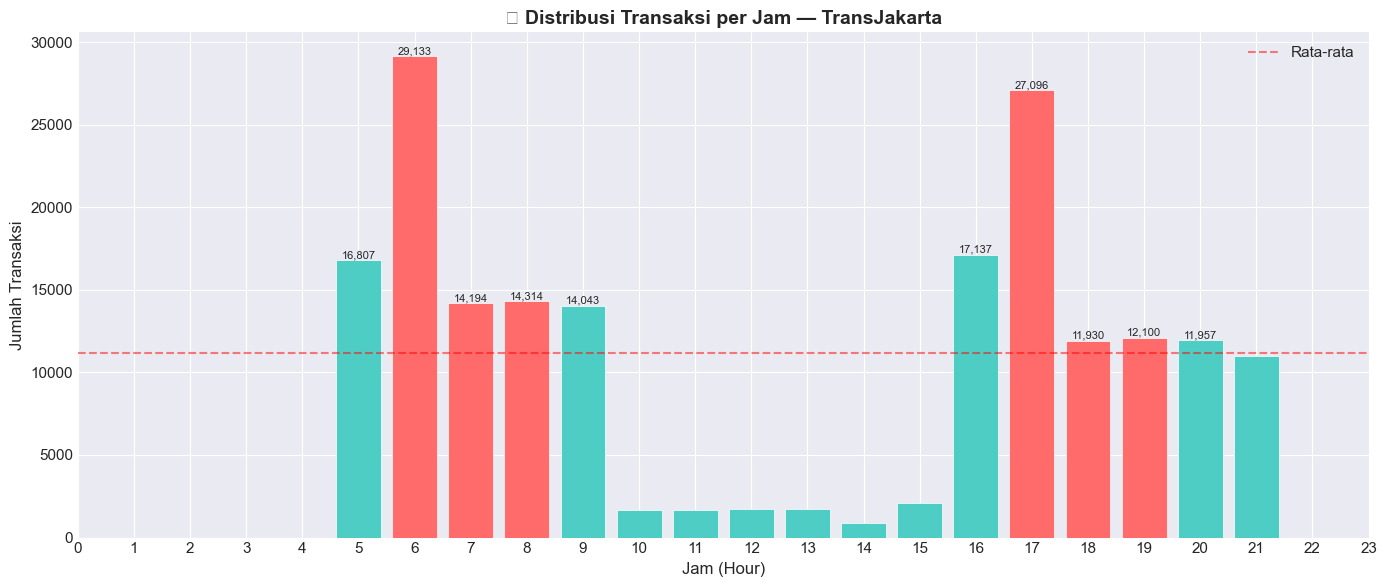


💡 INSIGHT:
   • Jam tersibuk: 06:00 dengan 29,133 transaksi
   • Jam sibuk pagi (06-09) dan sore (17-19) menunjukkan pola commuter/pekerja
   • Warna merah = jam sibuk (rush hour), biru = jam normal


In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#FF6B6B' if h in [6,7,8,17,18,19] else '#4ECDC4' for h in gold_hourly['tapInHour']]
bars = ax.bar(gold_hourly['tapInHour'], gold_hourly['total_transactions'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Jam (Hour)', fontsize=12)
ax.set_ylabel('Jumlah Transaksi', fontsize=12)
ax.set_title('📊 Distribusi Transaksi per Jam — TransJakarta', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.axhline(y=gold_hourly['total_transactions'].mean(), color='red', linestyle='--', alpha=0.5, label='Rata-rata')
ax.legend()
for bar in bars:
    height = bar.get_height()
    if height > gold_hourly['total_transactions'].mean():
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
peak_hour = gold_hourly.loc[gold_hourly['total_transactions'].idxmax()]
print(f"   • Jam tersibuk: {int(peak_hour['tapInHour']):02d}:00 dengan {int(peak_hour['total_transactions']):,} transaksi")
print(f"   • Jam sibuk pagi (06-09) dan sore (17-19) menunjukkan pola commuter/pekerja")
print(f"   • Warna merah = jam sibuk (rush hour), biru = jam normal")

### 2️⃣ Top 10 Corridor Tersibuk

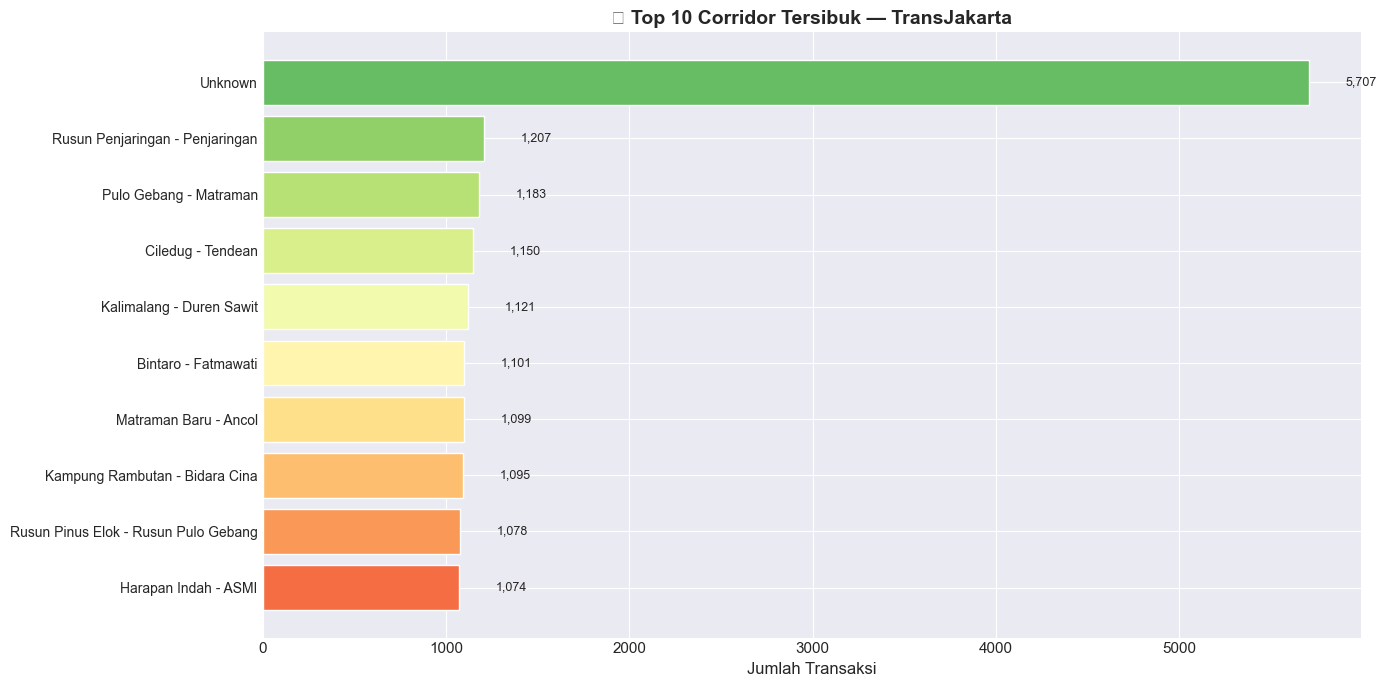


💡 INSIGHT:
   • Corridor tersibuk: Unknown
     dengan 5,707 transaksi
   • Top 3 corridor menguasai 4.3% total transaksi


In [16]:
fig, ax = plt.subplots(figsize=(14, 7))
top10 = gold_corridor.head(10)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 10))
bars = ax.barh(range(len(top10)), top10['total_transactions'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['corridorName'].str[:40], fontsize=10)
ax.set_xlabel('Jumlah Transaksi', fontsize=12)
ax.set_title('🏆 Top 10 Corridor Tersibuk — TransJakarta', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print(f"   • Corridor tersibuk: {top10.iloc[0]['corridorName']}")
print(f"     dengan {int(top10.iloc[0]['total_transactions']):,} transaksi")
print(f"   • Top 3 corridor menguasai {top10.head(3)['total_transactions'].sum()/gold_corridor['total_transactions'].sum()*100:.1f}% total transaksi")

### 3️⃣ Distribusi Metode Pembayaran (Bank)

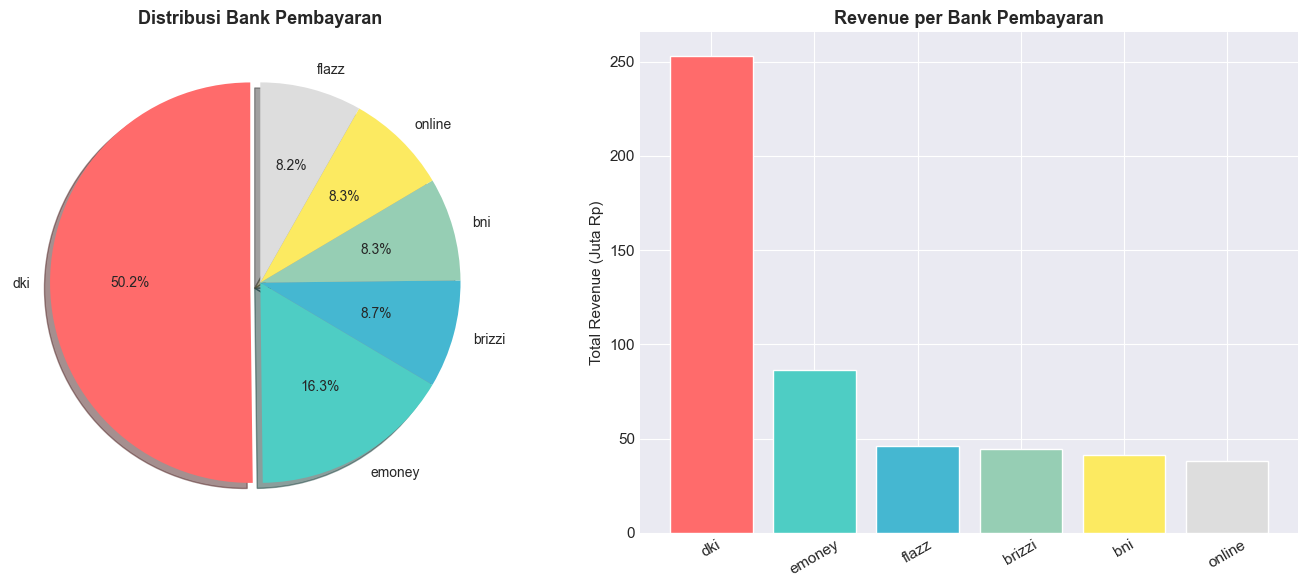


💡 INSIGHT:
   • Bank paling populer: dki (95,126 transaksi, 50.2%)
   • dki juga menghasilkan revenue tertinggi


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
bank_dist = df_silver['payCardBank'].value_counts().head(6)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FCEA61', '#DDD']
explode = [0.05] + [0] * (len(bank_dist) - 1)
axes[0].pie(bank_dist, labels=bank_dist.index, autopct='%1.1f%%', colors=colors,
            explode=explode, shadow=True, startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Distribusi Bank Pembayaran', fontsize=13, fontweight='bold')

# Bar chart
bank_revenue = df_silver.groupby('payCardBank')['payAmount'].sum().sort_values(ascending=False).head(6)
axes[1].bar(bank_revenue.index, bank_revenue.values / 1e6, color=colors, edgecolor='white')
axes[1].set_ylabel('Total Revenue (Juta Rp)', fontsize=11)
axes[1].set_title('Revenue per Bank Pembayaran', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print(f"   • Bank paling populer: {bank_dist.index[0]} ({bank_dist.values[0]:,} transaksi, {bank_dist.values[0]/bank_dist.sum()*100:.1f}%)")
print(f"   • {bank_dist.index[0]} juga menghasilkan revenue tertinggi")

### 4️⃣ Distribusi Jumlah Pembayaran

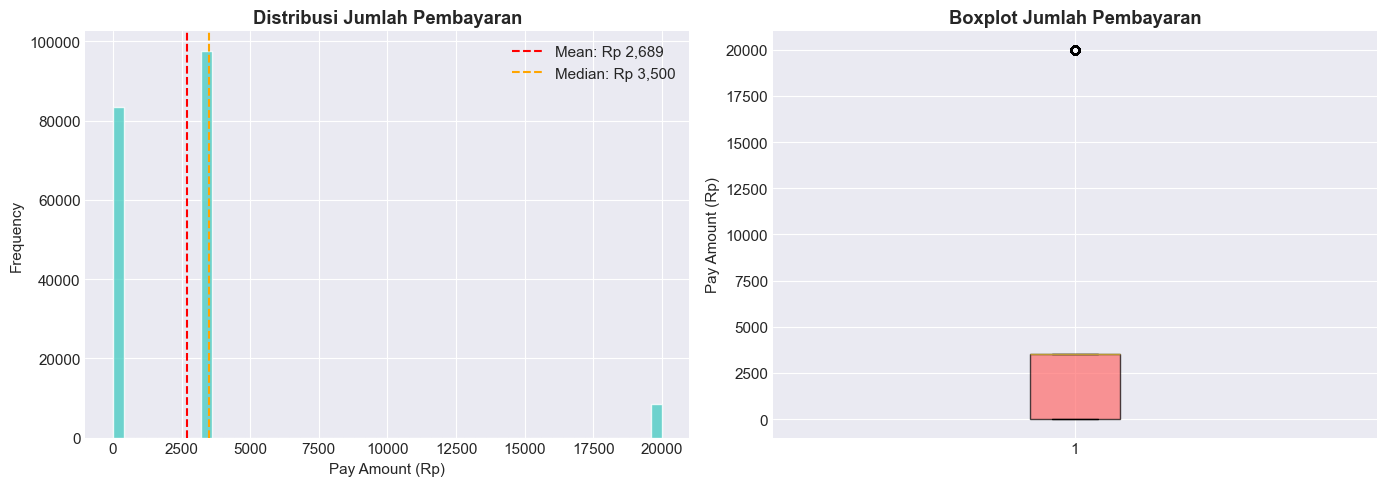


💡 INSIGHT:
   • Rata-rata pembayaran: Rp 2,689
   • Median pembayaran: Rp 3,500
   • Transaksi gratis (Rp 0): 44.0% — kemungkinan penumpang dengan kartu subsidi


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_silver['payAmount'], bins=50, color='#4ECDC4', edgecolor='white', alpha=0.8)
axes[0].axvline(df_silver['payAmount'].mean(), color='red', linestyle='--', label=f"Mean: Rp {df_silver['payAmount'].mean():,.0f}")
axes[0].axvline(df_silver['payAmount'].median(), color='orange', linestyle='--', label=f"Median: Rp {df_silver['payAmount'].median():,.0f}")
axes[0].set_xlabel('Pay Amount (Rp)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribusi Jumlah Pembayaran', fontweight='bold')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_silver['payAmount'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#FF6B6B', alpha=0.7))
axes[1].set_ylabel('Pay Amount (Rp)')
axes[1].set_title('Boxplot Jumlah Pembayaran', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print(f"   • Rata-rata pembayaran: Rp {df_silver['payAmount'].mean():,.0f}")
print(f"   • Median pembayaran: Rp {df_silver['payAmount'].median():,.0f}")
free_pct = (df_silver['payAmount'] == 0).sum() / len(df_silver) * 100
print(f"   • Transaksi gratis (Rp 0): {free_pct:.1f}% — kemungkinan penumpang dengan kartu subsidi")

### 5️⃣ Demografi Penumpang

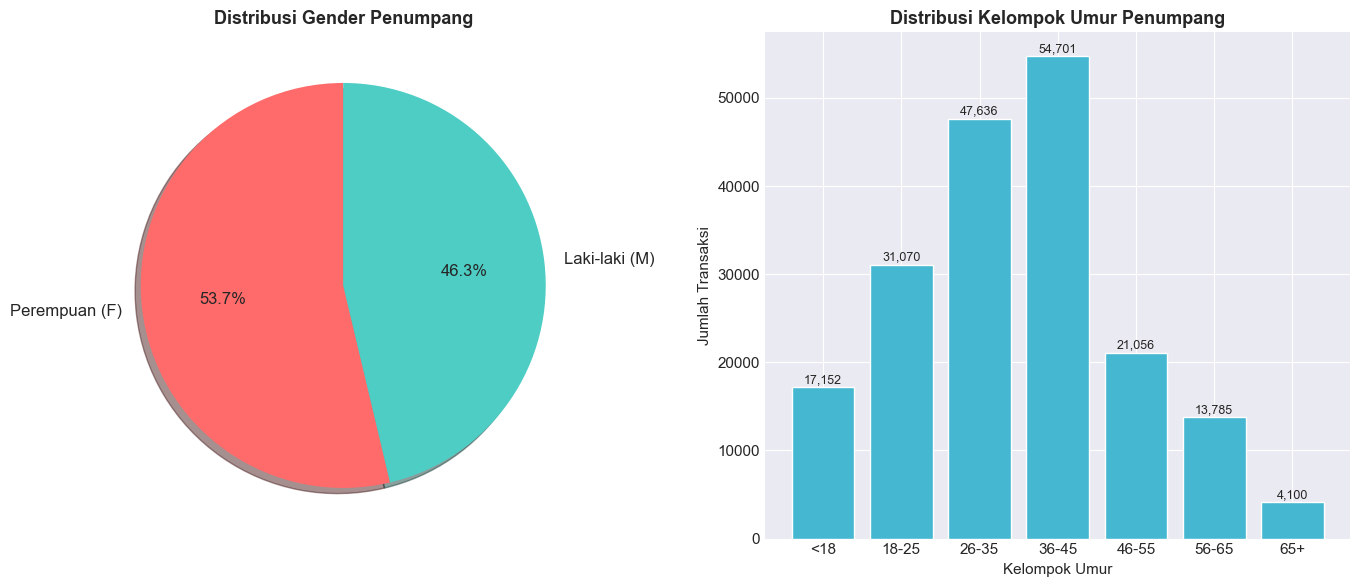


💡 INSIGHT:
   • Gender dominan: F (101,790 transaksi)
   • Kelompok umur terbanyak: 36-45 (54,701 transaksi)
   • Mayoritas penumpang adalah usia produktif — sesuai pola commuter


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gender distribution
gender_counts = df_silver['payCardSex'].value_counts()
colors_g = ['#FF6B6B', '#4ECDC4']
axes[0].pie(gender_counts, labels=['Perempuan (F)', 'Laki-laki (M)'] if gender_counts.index[0] == 'F' else ['Laki-laki (M)', 'Perempuan (F)'],
            autopct='%1.1f%%', colors=colors_g, shadow=True, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Distribusi Gender Penumpang', fontsize=13, fontweight='bold')

# Age group distribution
age_counts = df_silver['ageGroup'].value_counts().sort_index()
axes[1].bar(age_counts.index.astype(str), age_counts.values, color='#45B7D1', edgecolor='white')
axes[1].set_xlabel('Kelompok Umur')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_title('Distribusi Kelompok Umur Penumpang', fontsize=13, fontweight='bold')
for i, v in enumerate(age_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print(f"   • Gender dominan: {gender_counts.index[0]} ({gender_counts.values[0]:,} transaksi)")
dominant_age = age_counts.idxmax()
print(f"   • Kelompok umur terbanyak: {dominant_age} ({age_counts.max():,} transaksi)")
print(f"   • Mayoritas penumpang adalah usia produktif — sesuai pola commuter")

### 6️⃣ Trend Transaksi Harian

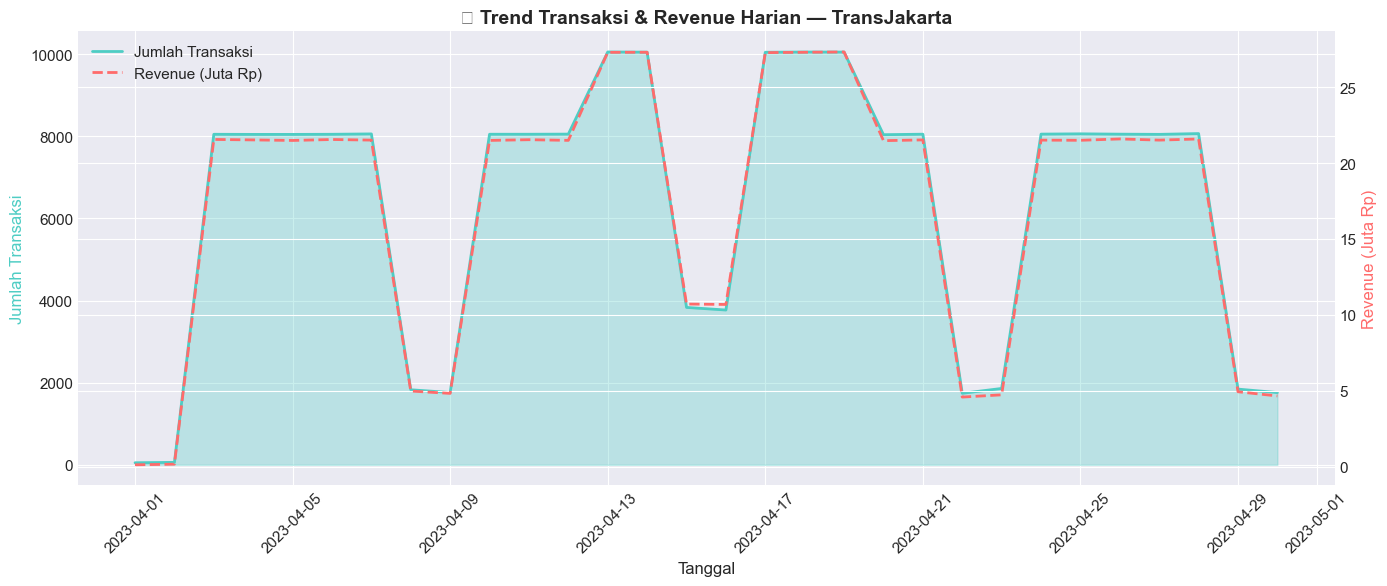


💡 INSIGHT:
   • Hari tersibuk: 2023-04-13 (10,052 transaksi)
   • Revenue tertinggi: Rp 27,316,000
   • Terdapat pola penurunan di akhir pekan (weekend)


In [20]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.fill_between(gold_daily['tapInDate'], gold_daily['total_transactions'], alpha=0.3, color='#4ECDC4')
ax1.plot(gold_daily['tapInDate'], gold_daily['total_transactions'], color='#4ECDC4', linewidth=2, label='Jumlah Transaksi')
ax1.set_xlabel('Tanggal', fontsize=12)
ax1.set_ylabel('Jumlah Transaksi', fontsize=12, color='#4ECDC4')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(gold_daily['tapInDate'], gold_daily['total_revenue']/1e6, color='#FF6B6B', linewidth=2, linestyle='--', label='Revenue (Juta Rp)')
ax2.set_ylabel('Revenue (Juta Rp)', fontsize=12, color='#FF6B6B')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('📈 Trend Transaksi & Revenue Harian — TransJakarta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
busiest_day = gold_daily.loc[gold_daily['total_transactions'].idxmax()]
print(f"   • Hari tersibuk: {busiest_day['tapInDate'].strftime('%Y-%m-%d')} ({int(busiest_day['total_transactions']):,} transaksi)")
print(f"   • Revenue tertinggi: Rp {gold_daily['total_revenue'].max():,.0f}")
print(f"   • Terdapat pola penurunan di akhir pekan (weekend)")

### 7️⃣ Distribusi Transaksi per Hari

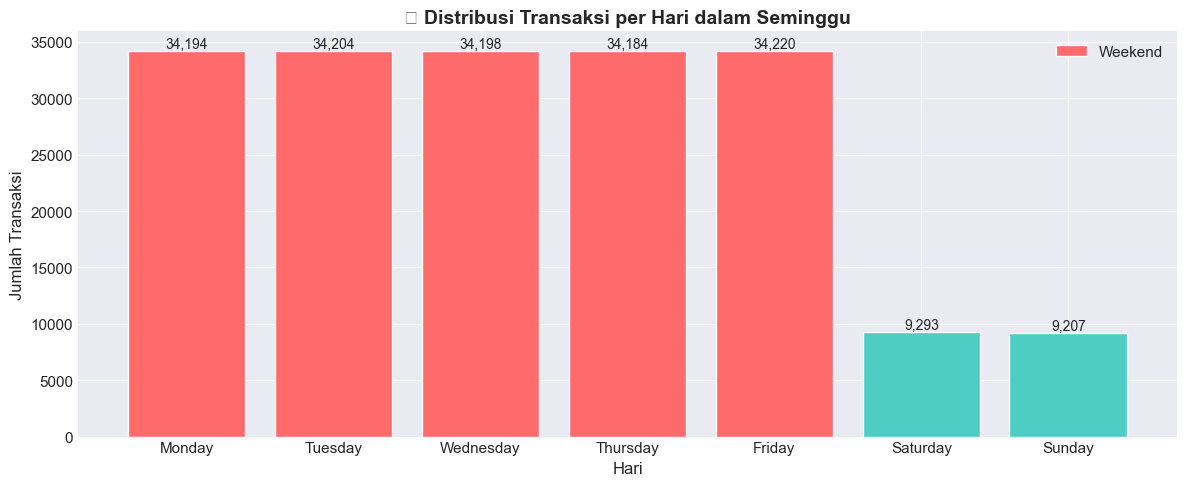


💡 INSIGHT:
   • Transaksi weekday jauh lebih tinggi dari weekend — pola commuter
   • Rata-rata weekday: 34,200 vs weekend: 9,250
   • Selisih: 270% lebih tinggi di weekday


In [21]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_silver['tapInDayOfWeek'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4ECDC4' if d in ['Saturday', 'Sunday'] else '#FF6B6B' for d in day_order]
bars = ax.bar(day_counts.index, day_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Hari', fontsize=12)
ax.set_ylabel('Jumlah Transaksi', fontsize=12)
ax.set_title('📊 Distribusi Transaksi per Hari dalam Seminggu', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', ha='center', va='bottom', fontsize=10)
ax.legend(['Weekend', 'Weekday'], loc='upper right')
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print(f"   • Transaksi weekday jauh lebih tinggi dari weekend — pola commuter")
wkday = day_counts[['Monday','Tuesday','Wednesday','Thursday','Friday']].mean()
wkend = day_counts[['Saturday','Sunday']].mean()
print(f"   • Rata-rata weekday: {wkday:,.0f} vs weekend: {wkend:,.0f}")
print(f"   • Selisih: {((wkday-wkend)/wkend*100):.0f}% lebih tinggi di weekday")

### 8️⃣ Peta Halte Populer

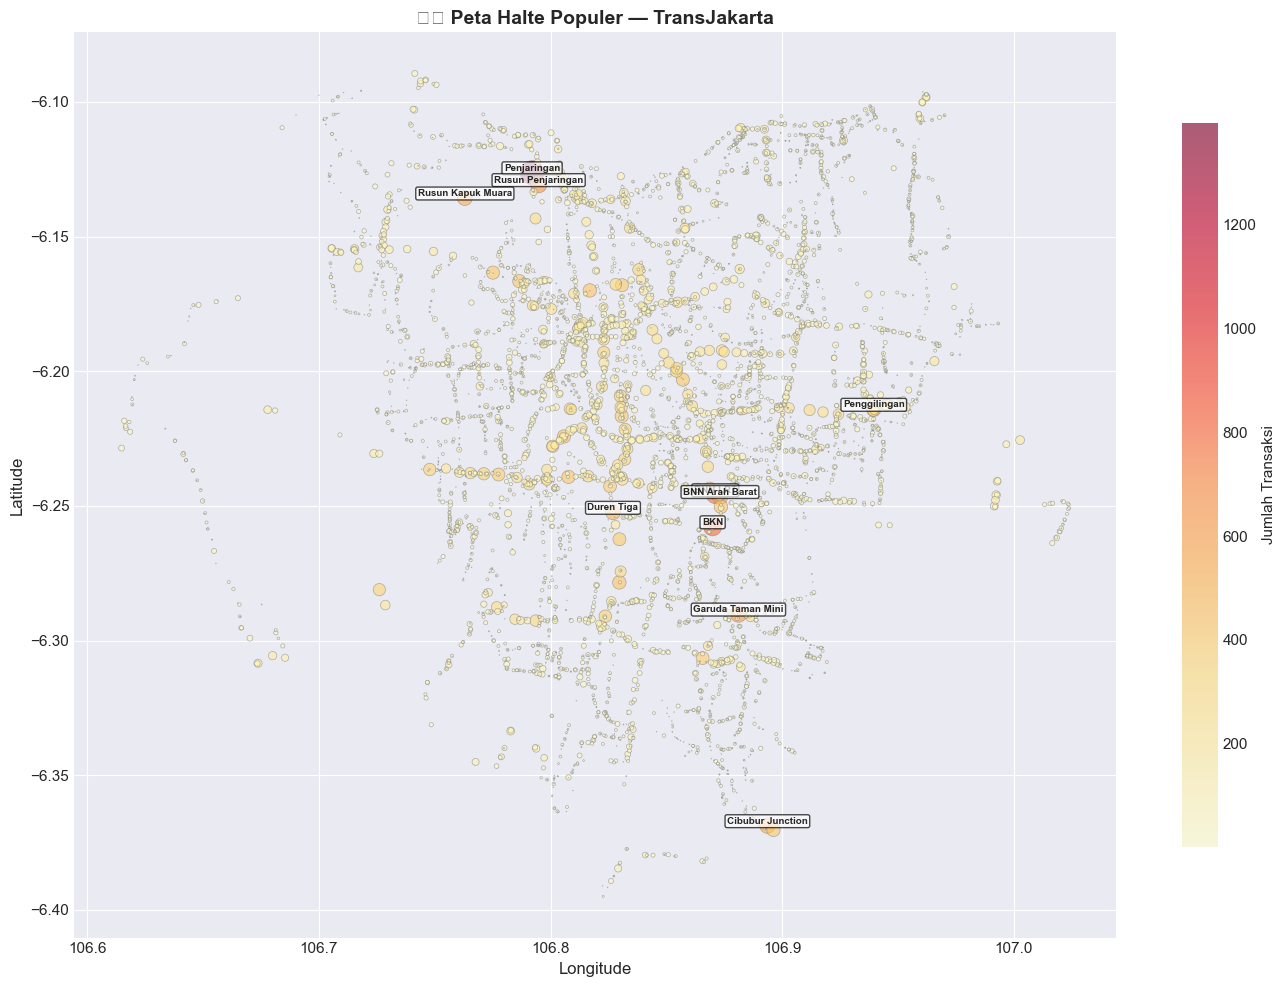


💡 INSIGHT:
   • Total halte unik: 5,278
   • Halte tersibuk:
     Penjaringan: 1,396 transaksi
     BKN: 794 transaksi
     BNN LRT: 758 transaksi
     Rusun Penjaringan: 654 transaksi
     Garuda Taman Mini: 642 transaksi


In [22]:
# Filter valid coordinates only
valid_coords = df_silver[(df_silver['tapInStopsLat'] != 0) & (df_silver['tapInStopsLon'] != 0)]
stop_traffic = valid_coords.groupby(['tapInStopsName', 'tapInStopsLat', 'tapInStopsLon']).size().reset_index(name='count')
stop_traffic = stop_traffic.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    stop_traffic['tapInStopsLon'], stop_traffic['tapInStopsLat'],
    s=stop_traffic['count'] / stop_traffic['count'].max() * 300,
    c=stop_traffic['count'], cmap='YlOrRd', alpha=0.6, edgecolors='gray', linewidth=0.5
)
plt.colorbar(scatter, label='Jumlah Transaksi', shrink=0.8)

# Label top 10 stops
for _, row in stop_traffic.head(10).iterrows():
    ax.annotate(row['tapInStopsName'][:20], (row['tapInStopsLon'], row['tapInStopsLat']),
                fontsize=7, ha='center', va='bottom', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('🗺️ Peta Halte Populer — TransJakarta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print(f"   • Total halte unik: {stop_traffic.shape[0]:,}")
print(f"   • Halte tersibuk:")
for i, row in stop_traffic.head(5).iterrows():
    print(f"     {row['tapInStopsName']}: {row['count']:,} transaksi")

## 💾 Export Data

Data yang sudah bersih akan di-export ke dua format:
1. **Excel (.xlsx)** — dengan multiple sheets untuk Silver Layer dan Gold Tables
2. **MySQL** — menggunakan SQLAlchemy + PyMySQL

> **Note:** Kolom PII asli (`payCardID_original`, `payCardName_original`) **TIDAK** di-export untuk menjaga privacy.

---

In [23]:
# === EXPORT TO EXCEL ===
print("💾 EXPORT TO EXCEL")
print("=" * 60)

# Prepare Silver data for export (remove internal & original PII columns)
export_exclude = ['_ingestion_timestamp', '_source_file', '_source_origin', '_record_id',
                  '_layer', '_cleaned_timestamp', '_quality_score',
                  'payCardID_original', 'payCardName_original']
silver_export = df_silver.drop(columns=[c for c in export_exclude if c in df_silver.columns])

# Convert date columns for Excel compatibility
if 'tapInDate' in silver_export.columns:
    silver_export['tapInDate'] = silver_export['tapInDate'].astype(str)

EXCEL_PATH = 'TransJakarta_Clean_Data.xlsx'

with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as writer:
    silver_export.to_excel(writer, sheet_name='Silver_Layer', index=False)
    gold_corridor.to_excel(writer, sheet_name='Gold_Corridor', index=False)
    gold_hourly.to_excel(writer, sheet_name='Gold_Hourly', index=False)
    gold_demographics.to_excel(writer, sheet_name='Gold_Demographics', index=False)
    gold_daily.to_excel(writer, sheet_name='Gold_Daily', index=False)

print(f"✅ Exported to Excel: {EXCEL_PATH}")
print(f"   Sheets: Silver_Layer, Gold_Corridor, Gold_Hourly, Gold_Demographics, Gold_Daily")

import os
file_size = os.path.getsize(EXCEL_PATH) / 1024 / 1024
print(f"   File size: {file_size:.2f} MB")

💾 EXPORT TO EXCEL
✅ Exported to Excel: TransJakarta_Clean_Data.xlsx
   Sheets: Silver_Layer, Gold_Corridor, Gold_Hourly, Gold_Demographics, Gold_Daily
   File size: 36.45 MB


In [24]:
# === EXPORT TO MySQL ===
print("💾 EXPORT TO MySQL")
print("=" * 60)

try:
    from sqlalchemy import create_engine
    
    # Konfigurasi MySQL — sesuaikan dengan setup lokal Anda
    MYSQL_USER = 'root'
    MYSQL_PASSWORD = ''  # Kosongkan jika tidak ada password
    MYSQL_HOST = 'localhost'
    MYSQL_PORT = '3306'
    MYSQL_DB = 'transjakarta_db'
    
    # Buat koneksi
    engine = create_engine(f'mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}')
    
    # Test koneksi
    with engine.connect() as conn:
        print("✅ MySQL connection successful!")
    
    # Export tables
    silver_export.to_sql('silver_transactions', engine, if_exists='replace', index=False, chunksize=5000)
    print("✅ Exported Silver Layer to MySQL: silver_transactions")
    
    gold_corridor.to_sql('gold_corridor_summary', engine, if_exists='replace', index=False)
    print("✅ Exported Gold Corridor Summary to MySQL: gold_corridor_summary")
    
    gold_hourly.to_sql('gold_hourly_traffic', engine, if_exists='replace', index=False)
    print("✅ Exported Gold Hourly Traffic to MySQL: gold_hourly_traffic")
    
    gold_demographics.to_sql('gold_demographics', engine, if_exists='replace', index=False)
    print("✅ Exported Gold Demographics to MySQL: gold_demographics")
    
    gold_daily.to_sql('gold_daily_trend', engine, if_exists='replace', index=False)
    print("✅ Exported Gold Daily Trend to MySQL: gold_daily_trend")
    
    print("\n✅ Semua data berhasil di-export ke MySQL!")
    
except ImportError:
    print("⚠️ pymysql tidak terinstall. Jalankan: pip install pymysql sqlalchemy")
    print("   Setelah install, jalankan ulang cell ini.")
except Exception as e:
    print(f"⚠️ MySQL connection failed: {e}")
    print("\n📝 Untuk menggunakan MySQL export:")
    print("   1. Pastikan MySQL Server sudah running")
    print("   2. Buat database: CREATE DATABASE transjakarta_db;")
    print("   3. Install library: pip install pymysql sqlalchemy")
    print("   4. Sesuaikan MYSQL_USER, MYSQL_PASSWORD, MYSQL_HOST di atas")
    print("   5. Jalankan ulang cell ini")

💾 EXPORT TO MySQL
⚠️ MySQL connection failed: (pymysql.err.OperationalError) (2003, "Can't connect to MySQL server on 'localhost' ([WinError 10061] No connection could be made because the target machine actively refused it)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)

📝 Untuk menggunakan MySQL export:
   1. Pastikan MySQL Server sudah running
   2. Buat database: CREATE DATABASE transjakarta_db;
   3. Install library: pip install pymysql sqlalchemy
   4. Sesuaikan MYSQL_USER, MYSQL_PASSWORD, MYSQL_HOST di atas
   5. Jalankan ulang cell ini


## ✅ Summary

### Proses yang telah dilakukan:

| No | Proses | Status |
|----|--------|--------|
| 1 | Data Understanding & Eksplorasi | ✅ |
| 2 | Bronze Layer — Raw Data Ingestion | ✅ |
| 3 | Silver Layer — Data Cleansing | ✅ |
| 4 | Data Quality Check (Completeness, Consistency, Validity, Uniqueness) | ✅ |
| 5 | Privacy Policy — Data Masking (payCardID, payCardName) | ✅ |
| 6 | Gold Layer — Aggregated Tables (4 tabel) | ✅ |
| 7 | Metadata Strategy — Data Dictionary | ✅ |
| 8 | Data Analysis — 8 Visualisasi dengan Insight | ✅ |
| 9 | Export ke Excel (.xlsx) | ✅ |
| 10 | Export ke MySQL | ✅ / ⚠️ |

### Key Insights:
1. **Pola Commuter**: Transaksi paling tinggi di jam sibuk pagi (06-09) dan sore (17-19)
2. **Weekday vs Weekend**: Transaksi weekday secara signifikan lebih tinggi dari weekend
3. **Demografi**: Mayoritas penumpang adalah usia produktif
4. **Gratis**: Terdapat proporsi signifikan transaksi Rp 0 (kemungkinan subsidi)
5. **Corridor**: Beberapa corridor mendominasi jumlah transaksi

---
*Project Data Engineer | Dibimbing*
*Dataset: Transjakarta - Public Transportation Transaction (Kaggle)*